# Long Short-Term Memory Networks (LSTMs)

A **Long Short-Term Memory network (LSTM)** is a gated recurrent neural-network architecture designed to make long-range dependencies easier to learn. Its defining feature is that it carries two state vectors through time:

- $c_t$: the **cell state**, an internal memory path
- $h_t$: the **hidden state**, the exposed or working representation

> **Important terminology:** An **LSTM cell** means the entire computational unit containing the gates and state-update equations. The **cell state** $c_t$ is one vector maintained by that unit. These two uses of “cell” should not be confused.

This notebook follows the notation and teaching style of `GRUs.ipynb`.

## Motivating example: a long-range dependency in text

Consider a language model trying to complete this passage:

> **I grew up in France. I later moved overseas, studied music, worked in several cities, and made friends from around the world. Even after all those years abroad, I can still speak fluent _____.**

A likely completion is **French**. The clue *France* occurs much earlier than the blank, with many unrelated words in between. To make the prediction, the model must preserve relevant information while processing the intervening text. This is a **long-range dependency**.

An LSTM can learn to handle this approximately as follows:

1. When it reads **France**, the candidate $\tilde c_t$ proposes a representation of the new country/language context, and the input gate $i_t$ allows relevant components to be written into $c_t$.
2. While it reads the intervening words, the forget gate $f_t$ can remain near 1 for those useful components, allowing the information to persist instead of being overwritten at every step.
3. Near the blank, the output gate $o_t$ can expose the relevant cell-state information through $h_t$, helping the prediction layer assign a high probability to **French**.

> The LSTM does not literally store the word *France* in one designated cell. It learns a distributed numerical representation across components of its state. The gates make retaining and later using that representation easier; they do not guarantee that every long-range dependency will be learned.

## 1. Why does an LSTM use a separate cell state?

A vanilla RNN repeatedly replaces its state with a nonlinear transformation:

$$
h_t = \tanh(W_xx_t + W_hh_{t-1} + b).
$$

Over many time steps, repeatedly applying recurrent matrices and activation derivatives can make gradients shrink or grow. Shrinking gradients make distant dependencies difficult to learn.

An LSTM separates two responsibilities:

| State | Main role |
|---|---|
| Cell state $c_t$ | Internal, longer-term storage with an additive update path |
| Hidden state $h_t$ | Filtered view of the memory used as the current output and in gate calculations |

This separation lets the model preserve information in $c_t$ without exposing all of it through $h_t$ at every step. It also creates a relatively direct path through time along which information and gradient signals can travel. LSTMs therefore **mitigate**, but do not completely eliminate, vanishing gradients. Exploding gradients can still occur and are often handled with gradient clipping.

## 2. Notation and state dimensions

At time step $t$:

| Symbol | Meaning | Shape for one example |
|---|---|---|
| $x_t$ | Current input | $(n_x,)$ |
| $h_{t-1}$ | Previous hidden state | $(n_h,)$ |
| $c_{t-1}$ | Previous cell state | $(n_h,)$ |
| $f_t$ | Forget gate | $(n_h,)$ |
| $i_t$ | Input gate | $(n_h,)$ |
| $o_t$ | Output gate | $(n_h,)$ |
| $\tilde c_t$ | Candidate cell content | $(n_h,)$ |
| $c_t$ | New cell state | $(n_h,)$ |
| $h_t$ | New hidden state | $(n_h,)$ |

$n_x$ is the number of input features and $n_h$ is the hidden-state size. Each gate is an $n_h$-dimensional **vector**, so different memory components can be controlled independently. Sigmoid gates take continuous values between 0 and 1; they are soft controls rather than binary switches.

### Trainable parameter dimensions

The forget gate, input gate, output gate, and candidate calculation each have an input-to-hidden matrix, a hidden-to-hidden matrix, and a bias:

| Calculation | Input weights | Shape | Recurrent weights | Shape | Bias | Shape |
|---|---|---|---|---|---|---|
| Forget gate $f_t$ | $W_f$ | $(n_h,n_x)$ | $U_f$ | $(n_h,n_h)$ | $b_f$ | $(n_h,)$ |
| Input gate $i_t$ | $W_i$ | $(n_h,n_x)$ | $U_i$ | $(n_h,n_h)$ | $b_i$ | $(n_h,)$ |
| Output gate $o_t$ | $W_o$ | $(n_h,n_x)$ | $U_o$ | $(n_h,n_h)$ | $b_o$ | $(n_h,)$ |
| Candidate $\tilde c_t$ | $W_c$ | $(n_h,n_x)$ | $U_c$ | $(n_h,n_h)$ | $b_c$ | $(n_h,)$ |

For example:

$$
W_f x_t:\quad (n_h,n_x)(n_x,) \longrightarrow (n_h,),
$$

$$
U_f h_{t-1}:\quad (n_h,n_h)(n_h,) \longrightarrow (n_h,).
$$

All terms in a gate equation therefore have shape $(n_h,)$ and can be added. The same reasoning applies to the other three calculations. Ignoring implementation-specific bias duplication, an LSTM layer has

$$
4\big(n_hn_x+n_h^2+n_h\big)
$$

trainable scalar parameters. The factor 4 comes from the three gates plus the candidate calculation.

## 3. LSTM computation, step by step

### Step 1: Forget gate

$$
f_t = \sigma(W_fx_t + U_fh_{t-1} + b_f)
$$

$f_t$ controls how much of the old cell state is retained. A component near 1 preserves the corresponding memory component; a component near 0 removes most of it.

### Step 2: Input gate

$$
i_t = \sigma(W_ix_t + U_ih_{t-1} + b_i)
$$

$i_t$ controls how much proposed new content is written into the cell state.

### Step 3: Candidate cell content

$$
\tilde c_t = \tanh(W_cx_t + U_ch_{t-1} + b_c)
$$

$\tilde c_t$ proposes new content that could be stored. Each component lies between $-1$ and $1$.

### Step 4: Cell-state update

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t
$$

The first term retains selected old memory; the second writes selected new content. The symbol $\odot$ means element-wise multiplication. Unlike the two weights in a GRU's interpolation, $f_t$ and $i_t$ are independently learned and do not have to sum to 1.

### Step 5: Output gate and hidden state

$$
o_t = \sigma(W_ox_t + U_oh_{t-1} + b_o)
$$

$$
h_t = o_t \odot \tanh(c_t)
$$

The output gate selects which parts of the updated internal memory are exposed as $h_t$. Consequently, information can remain in $c_t$ even when it is not strongly visible in the current hidden state.

### How the gates work together

It helps to view an LSTM update as three separate decisions: **what to keep**, **what to write**, and **what to reveal**. All three decisions are made from the current input $x_t$ and previous hidden state $h_{t-1}$, while the cell state $c_{t-1}$ provides the memory being edited.

#### Writing new information: where to write versus what to write

The input gate and candidate calculation answer different questions:

1. The **input gate** $i_t=\sigma(W_i x_t+U_i h_{t-1}+b_i)$ decides **which memory components may change, and by how much**. Its values lie between 0 and 1.
2. The **candidate** $\tilde c_t=\tanh(W_c x_t+U_c h_{t-1}+b_c)$ proposes **what values should be written**. Its values lie between $-1$ and 1.
3. Their element-wise product $i_t\odot\tilde c_t$ is the information actually offered to the cell state. A useful candidate component is not written when the corresponding input-gate component is near 0.

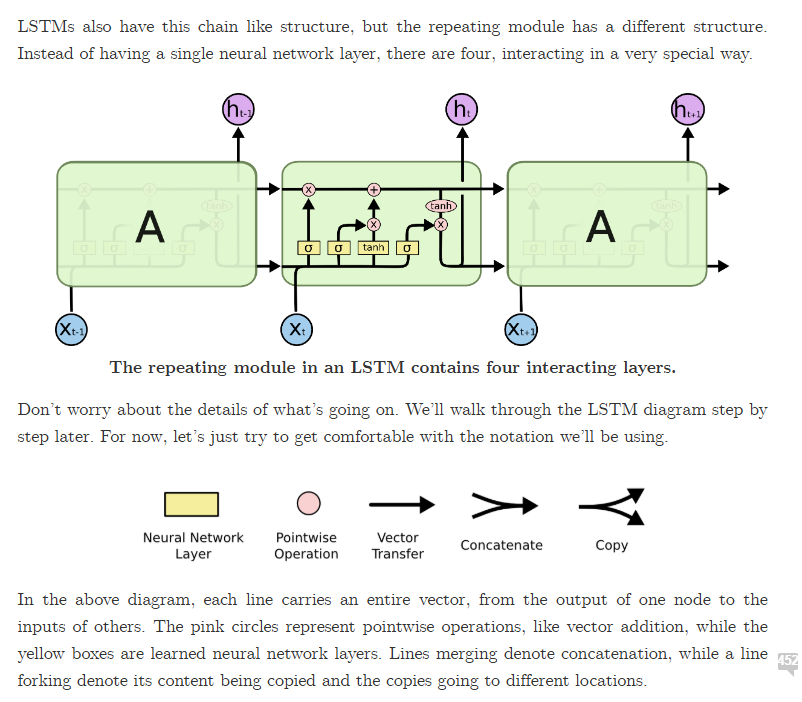

The full cell-state update combines a **keep path** and a **write path**:

$$
c_t=\underbrace{f_t\odot c_{t-1}}_{\text{retained old memory}}+\underbrace{i_t\odot\tilde c_t}_{\text{written new information}}.
$$

These operations happen component by component. For memory component $j$:

$$
c_{t,j}=f_{t,j}c_{t-1,j}+i_{t,j}\tilde c_{t,j}.
$$

This means the same time step can preserve one kind of information, erase another, and write something new elsewhere in the state vector.

#### Language-model intuition

Imagine that a language model has been processing one subject and then encounters a new subject. Conceptually, the gates can cooperate as follows:

| Stage | Conceptual action |
|---|---|
| Previous cell state $c_{t-1}$ | Contains distributed information about the earlier context |
| Forget gate $f_t$ | Suppresses components associated with the subject that is no longer relevant |
| Candidate $\tilde c_t$ | Proposes a representation of information about the new subject |
| Input gate $i_t$ | Selects how strongly and in which components that proposal should be stored |
| New cell state $c_t$ | Combines the retained context with the selected new information |
| Output gate $o_t$ | Reveals the parts of $c_t$ useful for the current prediction through $h_t$ |

> This is an intuition, not a hand-designed storage scheme. We do not assign a specific component to “subject” or any other concept. The network learns a distributed representation and useful gate behavior through backpropagation.

Both $c_t$ and $h_t$ are passed to the next time step, but only $h_t$ is normally exposed as the layer's sequence output.

## 4. Small numerical example

Consider one component of the state. Suppose

$$
c_{t-1}=0.8,\qquad f_t=0.9,\qquad i_t=0.2,\qquad \tilde c_t=-0.5.
$$

The updated cell-state component is

$$
c_t=(0.9)(0.8)+(0.2)(-0.5)=0.62.
$$

Most of the old memory was preserved, while a small amount of new negative content was written. If the output gate is $o_t=0.6$, then

$$
h_t=0.6\tanh(0.62)\approx0.331.
$$

The cell keeps $c_t=0.62$ internally, while exposing a gated, squashed value of approximately $0.331$. This illustrates why $c_t$ and $h_t$ are related but not interchangeable.

## 5. Why the cell-state path helps gradients

The cell update contains a direct additive path from $c_{t-1}$ to $c_t$:

$$
c_t=f_t\odot c_{t-1}+i_t\odot\tilde c_t.
$$

Looking only at this direct path, its local derivative is

$$
\frac{\partial c_t}{\partial c_{t-1}}=f_t.
$$

When the learned forget gates remain near 1, information and gradient signals can be carried across many steps with relatively little decay. The complete derivative also contains indirect paths because the gates depend on $h_{t-1}$, so this equation is an intuition for the direct memory path rather than the entire gradient calculation.

## 6. PyTorch example

PyTorch returns the complete sequence of hidden states and a tuple containing the final hidden and cell states.

In [ ]:
import torch

torch.manual_seed(0)

batch_size = 3
sequence_length = 5
input_size = 4
hidden_size = 6

lstm = torch.nn.LSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
)

x = torch.randn(batch_size, sequence_length, input_size)
output, (h_n, c_n) = lstm(x)

print("input shape:          ", x.shape)
print("all hidden states:    ", output.shape)
print("final hidden state:   ", h_n.shape)
print("final cell state:     ", c_n.shape)
print("Last output equals h_n:", torch.allclose(output[:, -1], h_n[0]))
print("h_n and c_n differ:     ", not torch.allclose(h_n, c_n))

For this one-layer, one-directional LSTM:

- `output` has shape $(B,T,n_h)$ and contains every exposed hidden state $h_t$.
- `h_n` has shape $(1,B,n_h)$ and contains the final hidden state.
- `c_n` has shape $(1,B,n_h)$ and contains the separate final cell state.
- `output[:, -1, :]` equals `h_n[0]`, but it generally does not equal `c_n[0]`.

For efficiency, PyTorch packs the four input matrices into `weight_ih_l0` with shape $(4n_h,n_x)$ and the four recurrent matrices into `weight_hh_l0` with shape $(4n_h,n_h)$. It similarly packs the biases. PyTorch uses the gate order input, forget, candidate, output: $(i,f,g,o)$.

In [ ]:
for name, parameter in lstm.named_parameters():
    print(f"{name:18s} {tuple(parameter.shape)}")

## 7. LSTM versus GRU

| Feature | LSTM | GRU |
|---|---|---|
| Recurrent states | Hidden state $h_t$ and cell state $c_t$ | One state $h_t$ |
| Gates | Input, forget, output | Reset, update |
| Candidate | $\tilde c_t$ | $\tilde h_t$ |
| Memory/output separation | Explicit | Combined in $h_t$ |
| Parameters at equal hidden size | Usually more | Usually fewer |
| Empirical performance | Task-dependent | Task-dependent |

An LSTM offers explicit control over storing information and exposing it. A GRU combines these roles into a simpler update. Neither architecture is universally better; the choice is normally evaluated for the particular dataset, task, and compute budget.

## 8. Common misunderstandings

- **$c_t$ is not a human-readable storage array.** It is a learned distributed numerical representation.
- **$h_t$ is not independent of $c_t$.** It is computed from the current cell state through the output gate.
- **The input and forget gates need not sum to 1.** The LSTM may preserve, erase, and write different amounts independently.
- **The gates are vectors, not scalar on/off switches.** Their components control different dimensions of memory.
- **An LSTM mitigates vanishing gradients; it does not guarantee perfect long-term memory.**

## 9. Summary

- An LSTM maintains a cell state $c_t$ for internal memory and a hidden state $h_t$ for exposed output.
- The forget gate chooses what old cell-state information to retain.
- The input gate chooses what candidate content to write.
- The output gate chooses which parts of the cell state to expose through $h_t$.
- The additive cell-state update provides a useful path for information and gradients across time.
- PyTorch returns both final states as `(h_n, c_n)`, making the separation explicit.